### 27.Style Transfer (Fast Neural Transfer)

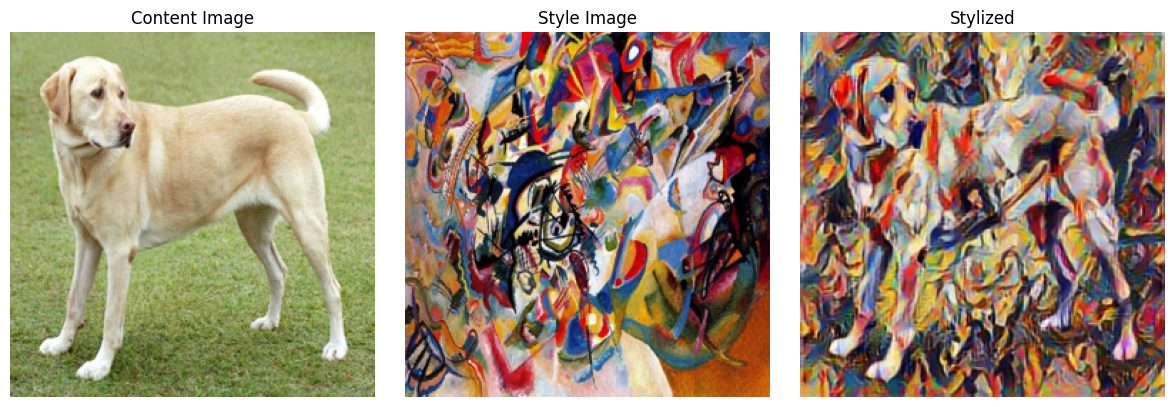

In [ ]:
# Apply fast neural style transfer using a pretrained TensorFlow Hub model to blend the content of one image with the artistic style of another.

import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load and preprocess images
def load_image(path, target_size=(256, 256)):
    img = Image.open(tf.keras.utils.get_file(path.split('/')[-1], path)).convert('RGB') # Load and convert
    img = img.resize(target_size) #resize to target size
    img = np.array(img) / 255.0 # Normalize to [0, 1]
    return tf.constant(img, dtype=tf.float32)

# Load content and style images
content_path = 'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg'

style_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg"

# Load content and style images
content_image = load_image(content_path)
style_image = load_image(style_url)

# Add batch dimensions
content_image = tf.expand_dims(content_image, axis=0)
style_image = tf.expand_dims(style_image, axis=0)

# Load the style transfer model from Tensorflow Hub
model = hub.load("https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2")

# Apply style transfer
stylized_image = model(content_image, style_image)[0] # Output image

# Display results
def show_image(img_tensor, title):
    img = tf.squeeze(img_tensor).numpy() # remove batch dimension
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
show_image(content_image, 'Content Image')
plt.subplot(1, 3, 2)
show_image(style_image, 'Style Image')

plt.subplot(1, 3, 3)
show_image(stylized_image, "Stylized")
plt.tight_layout()
plt.show()


### 28. Super-Resolution with EDSR

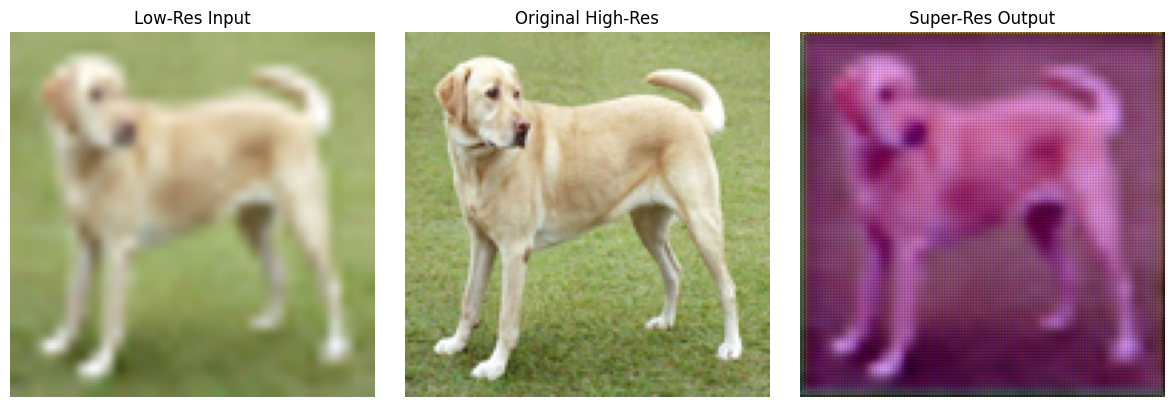

In [14]:
# Use a pretrained EDSR (Enhanced Deep Super-Resolution) model from TensorFlow Hub to upscale a low-resolution image to high-resolution.

import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load and preprocess images
def load_and_resize_image(url, scale=4):
    path = tf.keras.utils.get_file(url.split("/")[-1], url) # Download image
    img = Image.open(path).convert("RGB") # Open image and convert to RGB
    hr_img = img.resize((128, 128)) # resize image to high resolution
    lr_img = hr_img.resize((128 // scale, 128 // scale)) # resize image to low resolution
    lr_img = lr_img.resize((128, 128)) # resize low resolution image to 128x128
    return np.array(lr_img) / 255.0, np.array(hr_img) / 255.0 # Normalize to [0, 1] and return both images


# Load sample image
img_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"

lr_img, hr_img = load_and_resize_image(img_url)

# Convert low_res image to tensor and add batch dimension
lr_tensor = tf.convert_to_tensor(lr_img, dtype=tf.float32)[tf.newaxis, ...]

# Load EDSR model from TensorFlow Hub
model = hub.load("https://tfhub.dev/captain-pool/esrgan-tf2/1") # ESRGAN model is similar to EDSR

# Run Model to get super-res output
sr_tensor = model(lr_tensor) # Super resolution output
sr_img = tf.clip_by_value(sr_tensor[0], 0.0, 1.0).numpy() # Convert to numpy and clip values, remove batch dimension and clip value is to ensure the pixel values are between 0 and 1

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(lr_img)
plt.title("Low-Res Input")
plt.axis('off')
 
plt.subplot(1, 3, 2)
plt.imshow(hr_img)
plt.title("Original High-Res")
plt.axis('off')
 
plt.subplot(1, 3, 3)
plt.imshow(sr_img)
plt.title("Super-Res Output")
plt.axis('off')
plt.tight_layout()
plt.show()



### 29. Image Denoising Autoencoder

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - loss: 0.2015 - val_loss: 0.1289
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - loss: 0.1211 - val_loss: 0.1173
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - loss: 0.1144 - val_loss: 0.1131
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - loss: 0.1108 - val_loss: 0.1099
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - loss: 0.1083 - val_loss: 0.1082
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step


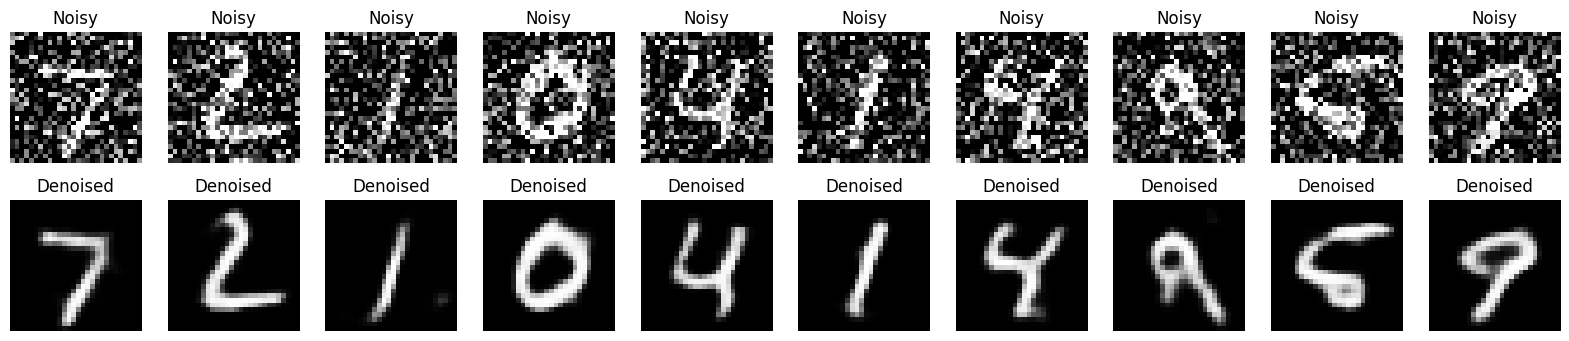

In [16]:
# Build a convolutional autoencoder using TensorFlow 2 to remove noise from images. We'll use MNIST digits with added Gaussian noise as the dataset.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, -1) # Add channel dimension
x_test = np.expand_dims(x_test, -1) # Add channel dimension

# Add Gaussian noise to training data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.) # clip means pixel values are between 0 and 1
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Build convolutional autoencoder
input_img = tf.keras.Input(shape=(28, 28, 1))
x = Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = MaxPooling2D(2, padding='same')(x)
x = Conv2D(16, 3, activation='relu', padding='same')(x)
x = MaxPooling2D(2, padding='same')(x)
x = Conv2D(16, 3, activation='relu', padding='same')(x)
x = UpSampling2D(2)(x)
x = Conv2D(32, 3, activation='relu', padding='same')(x)
x = UpSampling2D(2)(x)
decoded = Conv2D(1, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
autoencoder.fit(x_train_noisy, x_train, epochs=5, batch_size=128, shuffle=True, validation_split=0.1)

# Predict denoised images
decoded_imgs = autoencoder.predict(x_test_noisy[:10])

# Display original vs denoised images
plt.figure(figsize=(20, 4))
for i in range(10):
    # Noisy
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")
    
    # Denoised
    ax = plt.subplot(2, 10, i+11)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step


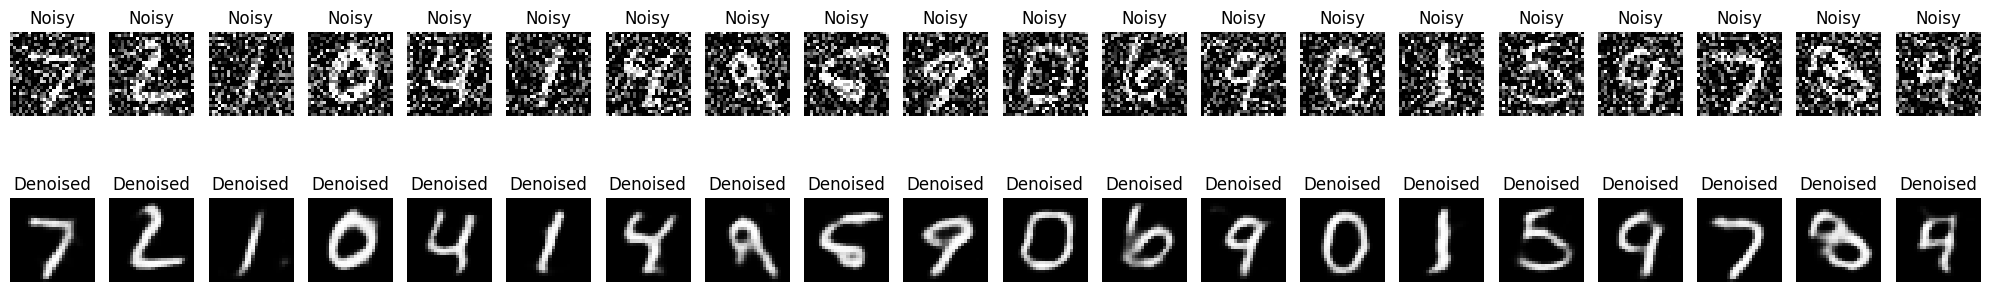

In [18]:
# Predict denoised images (Use 20 images instead of 10)
decoded_imgs = autoencoder.predict(x_test_noisy[:20])

# Display original vs denoised images
plt.figure(figsize=(20, 4))
for i in range(20):
    # Noisy images (Top row: 1 to 20)
    ax = plt.subplot(2, 20, i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")
    
    # Denoised images (Bottom row: 21 to 40)
    ax = plt.subplot(2, 20, i + 21)
    plt.imshow(decoded_imgs[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()


### 30. Depth Estimation from Monocular Images

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


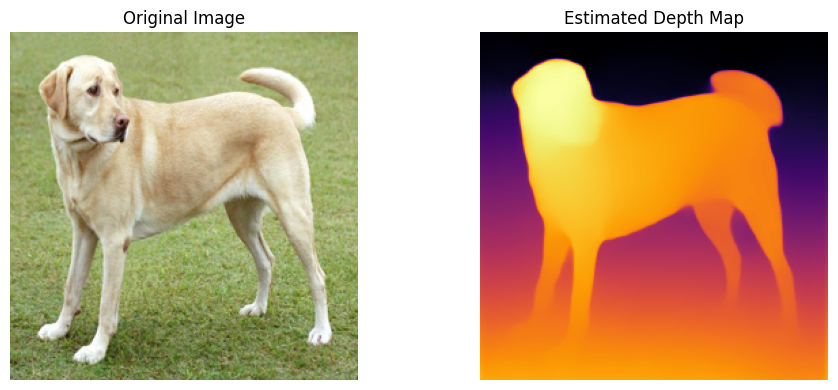

In [ ]:
# Use a pretrained monocular depth estimation model from TensorFlow Hub to predict a depth map from a single RGB image.

import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# --- 1. MODEL INITIALIZATION ---
# Load the PyTorch-converted MiDaS v2.1 small model.
# This legacy SavedModel structure requires explicit 'serve' tags.
MODEL_URL = "https://tfhub.dev/intel/midas/v2_1_small/1"
depth_model = hub.load(MODEL_URL, tags=['serve'])
infer_fn = depth_model.signatures['serving_default']


# --- 2. PREPROCESSING PIPELINE ---
def load_and_preprocess(image_url):
    """
    Downloads an image, scales it, and formats it to the NCHW shape format 
    expected by the MiDaS graph signature.
    """
    # Use the base filename from URL to prevent collision in local cache
    local_filename = os.path.basename(image_url)
    image_path = tf.keras.utils.get_file(local_filename, origin=image_url)
    
    # Open, standardize dimensions to 256x256, and convert to numpy float matrix
    pil_img = Image.open(image_path).convert('RGB').resize((256, 256)) 
    np_img = np.array(pil_img).astype(np.float32) / 255.0 
    
    # Convert to Tensor and attach Batch Dimension -> (1, 256, 256, 3) [NHWC]
    tensor_img = tf.convert_to_tensor(np_img)
    tensor_img = tf.expand_dims(tensor_img, 0) 
    
    # Transpose layout to Channels-First -> (1, 3, 256, 256) [NCHW]
    model_input = tf.transpose(tensor_img, perm=[0, 3, 1, 2])
    
    # Return both the model tensor and the native numpy image for quick plotting
    return model_input, np_img


# --- 3. EXECUTION ---
IMAGE_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
input_tensor, visual_img = load_and_preprocess(IMAGE_URL)

# Run inference through the static graph signature layer
output_dict = infer_fn(input_tensor)

# Extract depth frame and drop unused batch wrappers -> shape (256, 256)
depth_map = output_dict['default'][0] 


# --- 4. POST-PROCESSING & NORMALIZATION ---
# Min-Max Normalization to clamp values into a visible [0.0, 1.0] color distribution
depth_min = tf.reduce_min(depth_map)
depth_max = tf.reduce_max(depth_map)
normalized_depth = (depth_map - depth_min) / (depth_max - depth_min)


# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 4))

# Subplot 1: Render the original image asset
plt.subplot(1, 2, 1)
plt.imshow(visual_img) # Directly plotting the saved array (no inverse transpose needed)
plt.title("Original Image")
plt.axis('off')

# Subplot 2: Render the normalized heatmap output
plt.subplot(1, 2, 2)
plt.imshow(normalized_depth.numpy(), cmap='inferno')
plt.title("Estimated Depth Map")
plt.axis('off')

plt.tight_layout()
plt.show()

### 31. Text Classification with IMDB

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.7765 - loss: 0.4502 - val_accuracy: 0.8528 - val_loss: 0.3395
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.9024 - loss: 0.2475 - val_accuracy: 0.8618 - val_loss: 0.3257
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9379 - loss: 0.1692 - val_accuracy: 0.8584 - val_loss: 0.3508
Test Accuracy: 0.86


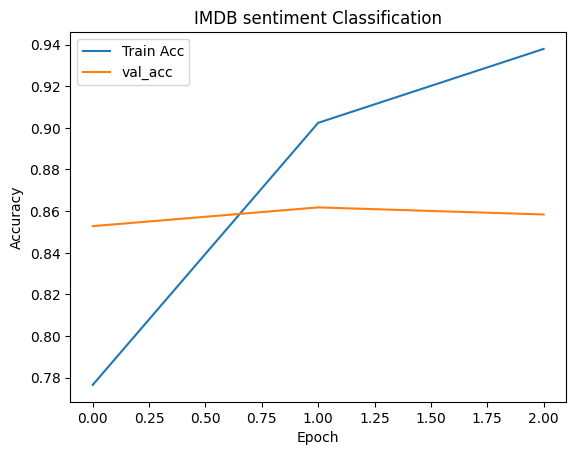

In [3]:
# Train a binary text classification model using TensorFlow 2 to classify IMDB movie reviews as positive or negative.

import tensorflow as tf
import matplotlib.pyplot as plt

# Load IMDB dataset (pre-tokenized, 10k word vocab)
vocab_size = 10000
(X_train, y_train),(X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

# Pad sequences to the same length
maxlen = 200
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, maxlen=maxlen)

# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=maxlen), # Word embedding
    
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)), # Bidirectional LSTM
    tf.keras.layers.Dense(64, activation='relu'), 
    tf.keras.layers.Dense(1, activation='sigmoid') # output: 0 (neg) or 1 (pos)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

# Evaluate on test data
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.2f}")

# Plot training / validation accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("IMDB sentiment Classification")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,369 (2.73 MB)

 Trainable params: 714,369 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.7484 - loss: 0.4869 - val_accuracy: 0.8528 - val_loss: 0.3406
Epoch 2/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.8887 - loss: 0.2783 - val_accuracy: 0.8626 - val_loss: 0.3162
Epoch 3/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.9219 - loss: 0.2119 - val_accuracy: 0.8682 - val_loss: 0.3213
Epoch 4/4
313/313 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.9452 - loss: 0.1590 - val_accuracy: 0.8624 - val_loss: 0.3526

🚀 Optimized Test Accuracy: 0.84


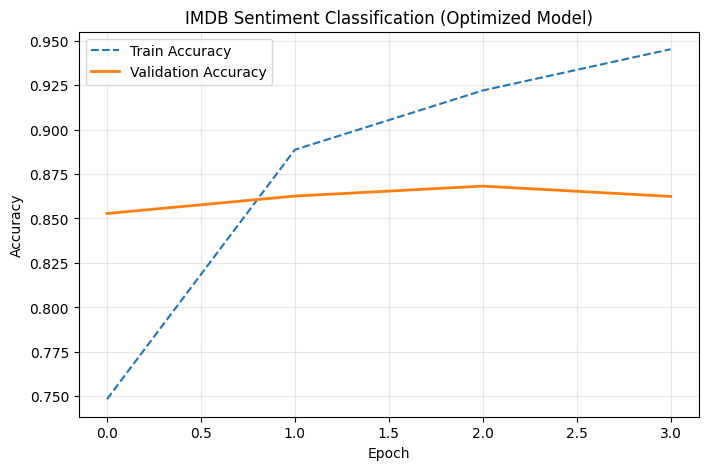

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION & DATASETS ---
vocab_size = 10000
maxlen = 200

# Load IMDB dataset (pre-tokenized)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

# Standardize text length via padding/truncating
# Explicitly specifying 'post' padding/truncating is often preferred for LSTMs
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen, padding='post', truncating='post')
X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test, maxlen=maxlen, padding='post', truncating='post')

# --- 2. ADVANCED MODEL ARCHITECTURE ---
model = tf.keras.Sequential([
    # Modern Keras standard: Define explicit input dimensions here
    tf.keras.Input(shape=(maxlen,)),
    
    # Embedding layer maps sparse token IDs to dense vectors
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64),
    
    # Bi-LSTM returning sequences to allow full sequence evaluation
    # Added regular dropout and recurrent dropout to mitigate overfitting
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)
    ),
    
    # Extracts the most powerful temporal features across the entire timeline
    tf.keras.layers.GlobalMaxPooling1D(),
    
    # Fully connected decision head
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3), # Extra regularization before final classification
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Display updated topology
model.summary()

# --- 3. COMPILATION & TRAINING ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Train the model 
history = model.fit(
    X_train, y_train, 
    epochs=4, 
    batch_size=64, 
    validation_split=0.2
)

# --- 4. EVALUATION & VISUALIZATION ---
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🚀 Optimized Test Accuracy: {acc:.2f}")

# Plot results
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', linestyle='--')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title("IMDB Sentiment Classification (Optimized Model)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 32. Tokenization with SubwordTextEncoder

In [1]:
# Use TensorFlow Datasets’ SubwordTextEncoder to build a subword-level tokenizer, then encode and decode sentences for NLP tasks like translation or classification.
import tensorflow_datasets as tfds
import tensorflow as tf

# Sample Sentences
corpus = [
    "TensorFlow is an end-to-end open-source platform for machine learning.",
    "Natural Language Processing is a fascinating field.",
    "Tokenization is the first step in NLP pipelines.",
    "Subword tokenization helps with rare words."
]

# Build SubWordTextEncoder from corpus
tokenizer = tfds.deprecated.text.SubwordTextEncoder.build_from_corpus(
    corpus, target_vocab_size=1000
)

# Print vocabulary size
print("SubWord Vocabulary Size: ", tokenizer.vocab_size)

# Encoder and decode a test sentence
test_sentence = "Subword tokenization is powerful for text models."
encoded = tokenizer.encode(test_sentence)
decoded = tokenizer.decode(encoded)

# Display results
print("\nOriginal Sentence:\n", test_sentence)
print("\nEncoded Tokens:\n", encoded)
print("\nDecoded Sentence:\n", decoded)
 
# Optional: visualize subwords
print("\nSubword Tokens:")
print([tokenizer.decode([token]) for token in encoded])

SubWord Vocabulary Size:  288

Original Sentence:
 Subword tokenization is powerful for text models.

Encoded Tokens:
 [27, 4, 1, 144, 143, 151, 133, 146, 134, 149, 140, 64, 17, 148, 133, 152, 148, 64, 141, 143, 132, 133, 140, 147, 78]

Decoded Sentence:
 Subword tokenization is powerful for text models.

Subword Tokens:
['Subword ', 'tokenization ', 'is ', 'p', 'o', 'w', 'e', 'r', 'f', 'u', 'l', ' ', 'for ', 't', 'e', 'x', 't', ' ', 'm', 'o', 'd', 'e', 'l', 's', '.']


###  33. Bidirectional LSTM for Sentiment Analysis

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 170s 504ms/step - accuracy: 0.7929 - loss: 0.4353 - val_accuracy: 0.8642 - val_loss: 0.3169
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 440ms/step - accuracy: 0.9107 - loss: 0.2359 - val_accuracy: 0.8662 - val_loss: 0.3326
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 448ms/step - accuracy: 0.9392 - loss: 0.1692 - val_accuracy: 0.8750 - val_loss: 0.3504
Test Accuracy: 0.87


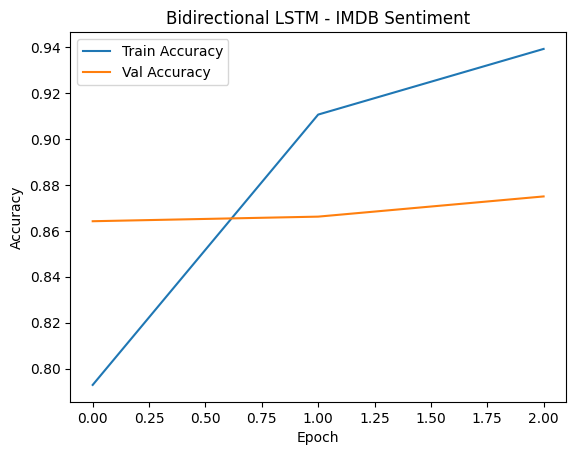

In [4]:
# Build a bidirectional LSTM model using TensorFlow 2 to perform sentiment classification on IMDB movie reviews (positive or negative).

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, preprocessing, layers, Sequential

# Load IMDB dataset with top 10,000 most frequent words
vocab_size = 10000
maxlen = 300
(X_train, y_train), (X_test, y_test) = datasets.imdb.load_data(num_words=vocab_size)

# Pad Sequences to a uniform length
X_train = preprocessing.sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = preprocessing.sequence.pad_sequences(X_test, maxlen=maxlen)

# Define Bi-LSTM Model
model = Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=128, input_length=maxlen),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 
# Train the model
history = model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)
 
# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.2f}")
 
# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Bidirectional LSTM - IMDB Sentiment")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### 34.Word Embeddings with Word2Vec (Custom Training)

In [9]:
import tensorflow as tf
import numpy as np

# Sample corpus
sentences = [
    "machine learning is fun",
    "deep learning is part of machine learning",
    "natural language processing is a field of ai",
    "word embeddings are learned representations",
    "tensorflow makes it easy to build models"
]

# Tokenize Corpus
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(sentences)
word2idx = tokenizer.word_index
idx2word = {v: k for k, v in word2idx.items()}
vocab_size = len(word2idx) + 1  # Fixed typo: voacb_size -> vocab_size

# Generate Skip-gram pairs
window_size = 2
sequences = tokenizer.texts_to_sequences(sentences)
pairs = []
for seq in sequences:
    for i, target_word in enumerate(seq):
        context_window = seq[max(i - window_size, 0): i] + seq[i + 1: i + window_size + 1]
        for context_word in context_window:
            pairs.append((target_word, context_word))

# Convert to numpy arrays
targets, contexts = zip(*pairs)
targets = np.array(targets)
contexts = np.array(contexts)
 
# One-hot encode targets
context_labels = tf.keras.utils.to_categorical(contexts, num_classes=vocab_size)
 
# Define skip-gram model
embedding_dim = 64
input_word = tf.keras.Input(shape=(1,))

# Added explicit name='embedding' here to match your lookup strategy
embedding = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, name='embedding')(input_word)

x = tf.keras.layers.Reshape((embedding_dim,))(embedding)
output = tf.keras.layers.Dense(vocab_size, activation='softmax')(x)
 
model = tf.keras.Model(inputs=input_word, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy')
 
# Train the model
model.fit(targets, context_labels, epochs=100, verbose=0)
 
# Extract and display learned embeddings
embedding_weights = model.get_layer('embedding').get_weights()[0]
for word, idx in word2idx.items():
    vec = embedding_weights[idx][:5]  # Show first 5 dims
    print(f"{word}: {vec.round(3)}")

learning: [ 0.322  0.168  0.346 -0.343 -0.296]
is: [ 0.032  0.199  0.121  0.055 -0.168]
machine: [ 0.238  0.281  0.22   0.021 -0.012]
of: [ 0.063  0.241  0.067  0.097 -0.107]
fun: [0.218 0.15  0.18  0.128 0.188]
deep: [0.237 0.204 0.224 0.16  0.213]
part: [ 0.34   0.323  0.183  0.075 -0.017]
natural: [-0.244  0.021  0.223  0.207 -0.242]
language: [ 0.084 -0.142  0.145  0.053 -0.317]
processing: [-0.036 -0.053  0.144  0.118 -0.247]
a: [ 0.116  0.085  0.066  0.094 -0.071]
field: [ 0.083  0.057 -0.093  0.054 -0.298]
ai: [ 0.27   0.325 -0.16   0.04   0.013]
word: [-0.23  -0.102 -0.059 -0.201  0.239]
embeddings: [-0.225  0.185 -0.115  0.015  0.049]
are: [-0.185 -0.215  0.072 -0.236  0.125]
learned: [-0.131 -0.238 -0.077 -0.262  0.255]
representations: [-0.141  0.174 -0.235 -0.174  0.011]
tensorflow: [ 0.245  0.103  0.091 -0.038  0.233]
makes: [ 0.01  -0.141 -0.187 -0.233  0.239]
it: [-0.025  0.073  0.026  0.09   0.302]
easy: [ 0.075  0.145 -0.023  0.138  0.326]
to: [ 0.023 -0.188 -0.181 -0.

### 35.Sequence-to-Sequence Translator (English–French)

In [ ]:
# Build a basic Seq2Seq (Encoder–Decoder) model using LSTM layers in TensorFlow 2 to translate short English sentences into French.

import tensorflow as tf
import numpy as np

# Sample Parallel corpus (tiny for demo)
english_sentences = ["hello", "how are you", "thank you", "good night"]
french_sentences = ["bonjour", "comment ça va", "merci", "bonne nuit"]

# TOkenize Source (English)
src_tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='')
